# 1-bit / 三元权重量化：BitNet b1.58 与 Bonsai

**对应博客篇目**：量化系列扩展篇 E4《1-bit / 三元权重量化——BitNet b1.58 与 Bonsai》
https://lrypcy.github.io/2026/09/22/llm-quant-E4-onebit-ternary-bonsai/

---

## 原理概述

主线 26 篇量化算法（RTN / GPTQ / AWQ / SmoothQuant / OmniQuant / QuaRot / LSQ / AdaRound …）
争的都是同一个优化目标 $\min_Q \mathcal{L}(W, Q(W))$ 里的**自由度**：scale、zero-point、
裁剪阈值、舍入方向、等价变换、旋转。**它们谁都没有动字母表**——权重的可取值始终是均匀整数网格。

1-bit / 三元量化动的是最底层那一格：

$$\mathcal{A}_{\text{INT4}} = \{-8,\dots,7\}\ (16\ \text{个电平}) \quad\longrightarrow\quad
\mathcal{A}_{\text{ternary}} = \{-1,0,+1\}\ (3\ \text{个电平})$$

后果是双重的：

1. **好**：$y=\sum_j x_j w_j$ 中 $w_j\in\{-1,0,+1\}$，乘法退化为加/减/跳过，可绕开浮点乘加单元；
2. **坏**：$\text{SQNR}\approx 6.02b$ dB 在 $b\to 1$ 时崩到 6 dB，且**这个损失不可能靠调 scale 找回来**——
   误差来自"网格太稀"，不是"网格没对齐"。

于是这条路只有一种活法：**让模型在训练时就看见这个损失，并学会在里面活着**。
本 notebook 量化这条路的收益与代价。

In [1]:
import json
import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

SEED = 0
OUT = "results"
os.makedirs(OUT, exist_ok=True)
rng = np.random.default_rng(SEED)
res = {}

print(f"随机种子: SEED={SEED}")


def bpw(alphabet_bits, group_size, scale_bits=16):
    """真实位宽 = 码本位宽 + 每组一个 scale 的摊销开销"""
    return alphabet_bits + scale_bits / group_size

随机种子: SEED=0


## ExpA：位宽账

三元/二值的"几位"极易被引述错。真实位宽必须把 scale 元数据摊销进去：

$$b_{\text{eff}} = \underbrace{\log_2|\mathcal{A}|}_{\text{码本}} + \underbrace{\frac{16}{g}}_{\text{每组一个 FP16 scale}}$$

三个必须记住的陷阱：

1. **"1.58 bit" 是不存 scale 的理论值**（$\log_2 3$），不是文件大小；
2. **三元按 2-bit slot 存时，1.71 退化成 2.125**，与 INT2 完全相同；
3. **MLX 的 1.25 是打包税**——MLX 要求每组同时给 scale 与 bias，只能令
   $s_{\text{mlx}}=2s_g,\ b_{\text{mlx}}=-s_g$ 来塞进 scale-only 的 1-bit 权重。

In [2]:
print("=" * 78)
print("ExpA  位宽账：字母表 + group scale 开销")
print("=" * 78)
print(f"{'format':38s} {'bpw':>7s} {'vs FP16':>8s}")
table_a = []
for name, b in [
    ("FP16 baseline", 16.0),
    ("INT4 g128", bpw(4.0, 128)),
    ("INT2 g128", bpw(2.0, 128)),
    ("Ternary ideal log2(3), no scale", np.log2(3)),
    ("Ternary g128 (PrismML)", bpw(np.log2(3), 128)),
    ("Ternary g128 (2-bit slot)", bpw(2.0, 128)),
    ("Binary g128 (GGUF Q1_0_g128)", bpw(1.0, 128)),
    ("Binary g128 (MLX scale+bias)", bpw(1.0, 128) + 16 / 128),
]:
    print(f"{name:38s} {b:7.3f} {16.0 / b:7.2f}x")
    table_a.append({"format": name, "bpw": round(float(b), 4), "vs_fp16": round(16.0 / b, 3)})
res["expA_bits_account"] = table_a

print("\n校验 PrismML 公开口径：")
print(f"  binary  g128 = {bpw(1.0,128):.4f} bpw, {16/bpw(1.0,128):.2f}x   (官方 1.125 / 14.2x)")
print(f"  ternary g128 = {bpw(np.log2(3),128):.4f} bpw, {16/bpw(np.log2(3),128):.2f}x  (官方 1.71 / 9.4x)")
print(f"  MLX 1-bit    = {bpw(1.0,128)+16/128:.4f} bpw           (官方 1.25)")
N = 27.3e9
print(f"  27.3B params: binary g128 -> {N*bpw(1.0,128)/8/1e9:.2f} GB (官方 3.9); "
      f"ternary g128 -> {N*bpw(np.log2(3),128)/8/1e9:.2f} GB (官方 5.9)")

ExpA  位宽账：字母表 + group scale 开销
format                                     bpw  vs FP16
FP16 baseline                           16.000    1.00x
INT4 g128                                4.125    3.88x
INT2 g128                                2.125    7.53x
Ternary ideal log2(3), no scale          1.585   10.09x
Ternary g128 (PrismML)                   1.710    9.36x
Ternary g128 (2-bit slot)                2.125    7.53x
Binary g128 (GGUF Q1_0_g128)             1.125   14.22x
Binary g128 (MLX scale+bias)             1.250   12.80x

校验 PrismML 公开口径：
  binary  g128 = 1.1250 bpw, 14.22x   (官方 1.125 / 14.2x)
  ternary g128 = 1.7100 bpw, 9.36x  (官方 1.71 / 9.4x)
  MLX 1-bit    = 1.2500 bpw           (官方 1.25)
  27.3B params: binary g128 -> 3.84 GB (官方 3.9); ternary g128 -> 5.84 GB (官方 5.9)


## 量化器：同一个字母表的三种写法

- **BitNet b1.58（absmean）**：$\gamma=\frac{1}{nm}\sum_{ij}|W_{ij}|$，
  $\widetilde{W}=\mathrm{RoundClip}(W/(\gamma+\epsilon),-1,1)$。$\gamma$ 是统计量，无参数无梯度。
- **deepgrove Bonsai（clamp+round）**：`w.clamp(-1,1).round()`，不除 $\gamma$，
  尺度交给 per-output-feature 的**可学习参数** `scales`（有梯度）。
- **PrismML Bonsai（分组 scale 的 1-bit）**：$w_i = s_g\cdot(2b_i-1)$，每 128 权重共享一个 FP16 的 $s_g$。

In [3]:
def tern(W, axis=-1, ls=True):
    """三元量化：absmean 归一化 + round（BitNet b1.58 口径）"""
    g = np.abs(W).mean(axis=axis, keepdims=True) + 1e-12
    T = np.clip(np.round(W / g), -1, 1)
    if ls:
        s = (W * T).sum(axis=axis, keepdims=True) / (T * T).sum(axis=axis, keepdims=True) + 1e-12
    else:
        s = g
    return T * s


def intq(W, bits, axis=-1, ls=True):
    """对称均匀整数量化，absmax scale"""
    qmax = 2 ** (bits - 1) - 1
    amax = np.abs(W).max(axis=axis, keepdims=True) + 1e-12
    T = np.clip(np.round(W / amax * qmax), -qmax, qmax)
    if ls:
        s = (W * T).sum(axis=axis, keepdims=True) / (T * T).sum(axis=axis, keepdims=True) + 1e-12
    else:
        s = amax / qmax
    return T * s


def binq(W, axis=-1):
    """二值量化：sign + 最小二乘 scale"""
    T = np.sign(W)
    s = (W * T).sum(axis=axis, keepdims=True) / np.sum(np.ones_like(W), axis=axis, keepdims=True)
    return T * s


def grouped(W, g, fn):
    m, n = W.shape
    return fn(W.reshape(m, n // g, g), axis=-1).reshape(m, n)

## ExpB：字母表 × 粒度的重建误差

权重矩阵 512×512，标准高斯 + 1% 幅度 ×8 的重尾 outlier——近似 LLM 权重的重尾特性。
参照系是 INT4 / INT3 / INT2 的均匀量化。

In [4]:
M, Nw = 512, 512
W = rng.normal(0, 1.0, size=(M, Nw))
W = np.where(rng.random((M, Nw)) < 0.01, W * 8.0, W)     # 1% 重尾 outlier
W /= np.sqrt((W ** 2).mean())

print("=" * 78)
print("ExpB  重建误差：字母表 x 粒度（W: 512x512 高斯 + 1% 重尾 outlier）")
print("=" * 78)
print(f"{'method':38s} {'bpw':>7s} {'rel err':>9s}")
rows_b = []
for bits in (4, 3, 2):
    for g in (None, 128, 32):
        Wh = intq(W, bits, axis=None) if g is None else grouped(W, g, lambda a, axis: intq(a, bits, axis))
        b = bits if g is None else bpw(bits, g)
        e = float(np.linalg.norm(W - Wh) / np.linalg.norm(W))
        name = f"INT{bits} " + ("per-tensor" if g is None else f"g{g}")
        print(f"{name:38s} {b:7.3f} {e*100:8.2f}%")
        rows_b.append({"method": name, "alphabet": f"INT{bits}", "group": g,
                       "bpw": round(float(b), 4), "rel_err": round(e, 5)})
for g in (None, 256, 128, 64, 32):
    Wh = tern(W, axis=None) if g is None else grouped(W, g, lambda a, axis: tern(a, axis))
    b = np.log2(3) if g is None else bpw(np.log2(3), g)
    e = float(np.linalg.norm(W - Wh) / np.linalg.norm(W))
    name = "Ternary " + ("per-tensor" if g is None else f"g{g}")
    print(f"{name:38s} {b:7.3f} {e*100:8.2f}%")
    rows_b.append({"method": name, "alphabet": "ternary", "group": g,
                   "bpw": round(float(b), 4), "rel_err": round(e, 5)})
for g in (None, 128):
    Wh = binq(W, axis=None) if g is None else grouped(W, g, lambda a, axis: binq(a, axis))
    b = 1.0 if g is None else bpw(1.0, g)
    e = float(np.linalg.norm(W - Wh) / np.linalg.norm(W))
    name = "Binary " + ("per-tensor" if g is None else f"g{g}")
    print(f"{name:38s} {b:7.3f} {e*100:8.2f}%")
    rows_b.append({"method": name, "alphabet": "binary", "group": g,
                   "bpw": round(float(b), 4), "rel_err": round(e, 5)})
res["expB_recon"] = rows_b

ExpB  重建误差：字母表 x 粒度（W: 512x512 高斯 + 1% 重尾 outlier）
method                                     bpw   rel err
INT4 per-tensor                          4.000    72.74%
INT4 g128                                4.125    25.27%
INT4 g32                                 4.500    14.97%
INT3 per-tensor                          3.000    80.72%
INT3 g128                                3.125    46.32%
INT3 g32                                 3.500    29.10%
INT2 per-tensor                          2.000    93.75%
INT2 g128                                2.125    69.23%
INT2 g32                                 2.500    52.87%
Ternary per-tensor                       1.585    66.21%
Ternary g256                             1.647    65.96%
Ternary g128                             1.710    65.69%
Ternary g64                              1.835    65.09%
Ternary g32                              2.085    63.85%
Binary per-tensor                        1.000    74.36%
Binary g128                          

### 关键对比：粒度边际收益随字母表变粗而坍塌

同样一笔位宽，花在 INT4 的粒度上和花在三元的粒度上，收益差一个数量级。

In [5]:
def gran_gain(alphabet):
    pts = {}
    for g in (None, 256, 128, 64, 32):
        if alphabet == "INT4":
            Wh = intq(W, 4, axis=None) if g is None else grouped(W, g, lambda a, axis: intq(a, 4, axis))
            b = 4.0 if g is None else bpw(4.0, g)
        elif alphabet == "INT2":
            Wh = intq(W, 2, axis=None) if g is None else grouped(W, g, lambda a, axis: intq(a, 2, axis))
            b = 2.0 if g is None else bpw(2.0, g)
        else:
            Wh = tern(W, axis=None) if g is None else grouped(W, g, lambda a, axis: tern(a, axis))
            b = np.log2(3) if g is None else bpw(np.log2(3), g)
        pts[g] = (float(b), float(np.linalg.norm(W - Wh) / np.linalg.norm(W)))
    return pts


print("粒度边际收益（per-tensor -> g32）：")
gain = {}
for ab in ("INT4", "INT2", "ternary"):
    pts = gran_gain(ab)
    e0, e1 = pts[None][1], pts[32][1]
    b0, b1 = pts[None][0], pts[32][0]
    print(f"  {ab:8s}: 误差 {e0*100:6.2f}% -> {e1*100:6.2f}%  (降 {(1-e1/e0)*100:5.1f}%)   "
          f"位宽 {b0:.3f} -> {b1:.3f} bpw (涨 {(b1/b0-1)*100:5.1f}%)")
    gain[ab] = {"err_pt": round(e0, 5), "err_g32": round(e1, 5),
                "err_drop_pct": round((1 - e1 / e0) * 100, 2),
                "bpw_pt": round(b0, 4), "bpw_g32": round(b1, 4),
                "bpw_gain_pct": round((b1 / b0 - 1) * 100, 2)}
res["expB_granularity_gain"] = gain

T_pt = np.clip(np.round(W / (np.abs(W).mean() + 1e-12)), -1, 1)
print(f"\n三元码本中 0 的占比（per-tensor absmean）: {(T_pt == 0).mean()*100:.1f}%")
res["expB_ternary_zero_ratio"] = round(float((T_pt == 0).mean()), 4)

粒度边际收益（per-tensor -> g32）：
  INT4    : 误差  72.74% ->  14.97%  (降  79.4%)   位宽 4.000 -> 4.500 bpw (涨  12.5%)
  INT2    : 误差  93.75% ->  52.87%  (降  43.6%)   位宽 2.000 -> 2.500 bpw (涨  25.0%)
  ternary : 误差  66.21% ->  63.85%  (降   3.6%)   位宽 1.585 -> 2.085 bpw (涨  31.5%)

三元码本中 0 的占比（per-tensor absmean）: 32.7%


## ExpC：权重误差 → 输出误差

激活 $X$ 含 5% 幅度 ×10 的 outlier 通道。看权重重建误差是被平均掉，还是原样传出去。

In [6]:
X = rng.normal(0, 1.0, size=(256, Nw))
X[:, rng.choice(Nw, size=Nw // 20, replace=False)] *= 10.0   # 5% outlier 通道
Y = X @ W.T

print("=" * 78)
print("ExpC  权重误差 -> 输出误差（激活含 5% outlier 通道 x10）")
print("=" * 78)
print(f"{'method':38s} {'out rel err':>12s} {'cosine':>10s}")
rows_c = []
for name, Wh in [
    ("INT4 g128", grouped(W, 128, lambda a, axis: intq(a, 4, axis))),
    ("INT2 g128", grouped(W, 128, lambda a, axis: intq(a, 2, axis))),
    ("Ternary g128", grouped(W, 128, lambda a, axis: tern(a, axis))),
    ("Ternary per-tensor", tern(W, axis=None)),
    ("Binary g128", grouped(W, 128, lambda a, axis: binq(a, axis))),
]:
    Yh = X @ Wh.T
    rel = float(np.linalg.norm(Y - Yh) / np.linalg.norm(Y))
    cos = float((Y * Yh).sum() / (np.linalg.norm(Y) * np.linalg.norm(Yh)))
    print(f"{name:38s} {rel*100:11.2f}% {cos:10.4f}")
    rows_c.append({"method": name, "out_rel_err": round(rel, 5), "cosine": round(cos, 4)})
res["expC_output"] = rows_c

ExpC  权重误差 -> 输出误差（激活含 5% outlier 通道 x10）
method                                  out rel err     cosine
INT4 g128                                    25.42%     0.9671
INT2 g128                                    68.86%     0.7251
Ternary g128                                 66.14%     0.7501
Ternary per-tensor                           66.43%     0.7474
Binary g128                                  74.24%     0.6699


## ExpD：得到三元权重的三条路径

这是整套实验里最关键的一个。`round()` / `sign()` 的导数**几乎处处为 0**，
必须靠 **STE + 影子权重（shadow weights）** 让训练跑起来：

- **影子权重** $W$：全精度浮点，唯一接收梯度更新的对象；
- **量化权重** $\hat{W}$：前向实际使用的离散权重，由 $\hat{W}=\text{quantize}(W)$ 即时生成；
- **反向**：$\partial L/\partial W := \partial L/\partial \hat{W}$（STE，假装 quantize 是恒等映射）；
- **部署**：只留 $\hat{W}$ 与 scale，丢弃 $W$。

PyTorch 里一行就够（deepgrove Bonsai 的写法）：`w_q = w + (quantizer(w) - w).detach()`。
这里没有 torch，我们用 numpy 手写同样的机制，对比三条路径：

- **A｜训完再量化（PTQ）**：全精度训练 → 最后 `quantize()`
- **B｜随机初始化 + 量化在环**（BitNet / deepgrove Bonsai 式原生低比特）
- **C｜全精度解 + 量化在环微调**（QAT fine-tune，PrismML Bonsai 可能走的路）

In [7]:
d_in, d_out = 64, 32
Xtr = rng.normal(0, 1, size=(4096, d_in))
Xte = rng.normal(0, 1, size=(1024, d_in))
W0 = rng.normal(0, 1 / np.sqrt(d_in), size=(d_out, d_in))
Ytr = Xtr @ W0.T + 0.05 * rng.normal(size=(4096, d_out))
Yte = Xte @ W0.T + 0.05 * rng.normal(size=(1024, d_out))


def q(Ws):
    """三元量化：per-output-feature absmean scale（BitNet 口径）"""
    g = np.abs(Ws).mean(axis=1, keepdims=True) + 1e-12
    return np.clip(np.round(Ws / g), -1, 1) * g


def step(Ws, in_loop, lr):
    """STE：前向用量化权重，反向 dW_hat/dW := 1"""
    Wf = q(Ws) if in_loop else Ws
    return Ws - lr * (((Xtr @ Wf.T - Ytr).T @ Xtr) / len(Xtr))


def mse(Wm):
    return float(np.mean(((Xte @ Wm.T) - Yte) ** 2))

In [8]:
STEPS, LR_FP, LR_STE = 1200, 0.05, 1e-3
Ws_fp = rng.normal(0, 1 / np.sqrt(d_in), size=(d_out, d_in)) * 0.1
for _ in range(STEPS):
    Ws_fp = step(Ws_fp, False, LR_FP)
A = mse(q(Ws_fp))

Ws_B = rng.normal(0, 1 / np.sqrt(d_in), size=(d_out, d_in)) * 0.1
Ws_C = Ws_fp.copy()
curve = {"A": [], "B": [], "C": []}
for t in range(STEPS):
    Ws_B = step(Ws_B, True, LR_STE)
    Ws_C = step(Ws_C, True, LR_STE)
    if t % 50 == 0 or t == STEPS - 1:
        curve["A"].append(A)
        curve["B"].append(mse(q(Ws_B)))
        curve["C"].append(mse(q(Ws_C)))
B, C = mse(q(Ws_B)), mse(q(Ws_C))
FP = mse(Ws_fp)

print("=" * 78)
print("ExpD  得到三元权重的三条路径（手写 STE，SGD 1200 步）")
print("=" * 78)
print(f"{'path':44s} {'test MSE':>12s}")
print(f"{'参考 全精度解（不量化，上界）':44s} {FP:12.5f}")
print(f"{'A 训完再量化 PTQ':44s} {A:12.5f}")
print(f"{'B 随机初始化 + 量化在环（原生低比特）':44s} {B:12.5f}")
print(f"{'C 全精度解 + 量化在环微调（QAT）':44s} {C:12.5f}")
print(f"\nC 相对 A 的改善: {(1-C/A)*100:.1f}%   A/C = {A/C:.2f}x   "
      f"距全精度上界仍有 {A/FP:.0f}x（A）/ {C/FP:.0f}x（C）")

Ws_dead = rng.normal(0, 1 / np.sqrt(d_in), size=(d_out, d_in)) * 0.1
print(f"\n对照：无 STE（round 导数=0）1200 步后 test MSE = {mse(q(Ws_dead)):.5f}"
      f"（等于初始值，训练完全停滞）")

res["expD_paths"] = {
    "fp_upper_bound": round(FP, 6), "A_ptq": round(A, 6),
    "B_native_ste": round(B, 6), "C_qat_finetune": round(C, 6),
    "no_ste_baseline": round(mse(q(Ws_dead)), 6),
    "C_improve_vs_A_pct": round((1 - C / A) * 100, 2),
    "gap_to_fp_bound_A": round(A / FP, 1), "gap_to_fp_bound_C": round(C / FP, 1),
    "curve_step": 50, "curve": curve,
}

ExpD  得到三元权重的三条路径（手写 STE，SGD 1200 步）
path                                             test MSE
参考 全精度解（不量化，上界）                                   0.00253
A 训完再量化 PTQ                                       0.26194
B 随机初始化 + 量化在环（原生低比特）                             0.34660
C 全精度解 + 量化在环微调（QAT）                              0.23432

C 相对 A 的改善: 10.5%   A/C = 1.12x   距全精度上界仍有 103x（A）/ 93x（C）

对照：无 STE（round 导数=0）1200 步后 test MSE = 1.00320（等于初始值，训练完全停滞）


## 图 1：字母表 × 粒度的误差-位宽前沿

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for ab, marker, color in [("INT4", "o", "tab:blue"), ("INT3", "s", "tab:cyan"),
                          ("INT2", "^", "tab:orange"), ("ternary", "D", "tab:red"),
                          ("binary", "v", "tab:green")]:
    sel = [r for r in rows_b if r["alphabet"] == ab]
    xs = [r["bpw"] for r in sel]
    ys = [r["rel_err"] * 100 for r in sel]
    if xs:
        ax.plot(xs, ys, marker + "-", color=color, label=ab)
        for x, y, r in zip(xs, ys, sel):
            ax.annotate(r["method"].split()[-1], (x, y), textcoords="offset points",
                        xytext=(4, 3), fontsize=7, color=color)
ax.set_xlabel("true bits per weight")
ax.set_ylabel("weight reconstruction rel. error (%)")
ax.set_title("Alphabet x granularity: error vs true bit budget")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
p1 = os.path.join(OUT, "alphabet_granularity_frontier.png")
fig.savefig(p1, dpi=130)
plt.close(fig)
print("[saved]", p1)

[saved] results/alphabet_granularity_frontier.png


## 图 2：粒度边际收益随字母表坍塌

同一笔位宽（+12%~32%），花在 INT4 的粒度上换来 79.4% 的误差下降，
花在三元的粒度上只换来 3.6%。**字母表越粗，粒度越不值钱**——这是 Bonsai 敢用 g128 的原因。

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
keys = [None, 256, 128, 64, 32]
for ab, color in [("INT4", "tab:blue"), ("INT2", "tab:orange"), ("ternary", "tab:red")]:
    pts = gran_gain(ab)
    xs = [pts[k][0] for k in keys]
    ys = [pts[k][1] * 100 for k in keys]
    ax.plot(range(len(keys)), ys, "o-", color=color, label=ab)
    for i, (x, y) in enumerate(zip(xs, ys)):
        ax.annotate(f"{x:.2f}bpw", (i, y), textcoords="offset points",
                    xytext=(4, -9), fontsize=7, color=color)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(["per-tensor", "g256", "g128", "g64", "g32"])
ax.set_ylabel("weight reconstruction rel. error (%)")
ax.set_title("Granularity payoff collapses as alphabet shrinks")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
p2 = os.path.join(OUT, "granularity_diminishing_return.png")
fig.savefig(p2, dpi=130)
plt.close(fig)
print("[saved]", p2)

[saved] results/granularity_diminishing_return.png


## 图 3：三条路径与容量鸿沟

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax = axes[0]
xs = np.arange(len(curve["A"])) * 50
ax.plot(xs, curve["A"], "o-", color="tab:blue", label="A: train FP -> quantize (PTQ)")
ax.plot(xs, curve["B"], "s-", color="tab:orange", label="B: random init + STE in loop")
ax.plot(xs, curve["C"], "^-", color="tab:green", label="C: FP init + STE finetune (QAT)")
ax.axhline(FP, ls="--", color="gray", label=f"FP16 bound ({FP:.4f})")
ax.set_xlabel("SGD step")
ax.set_ylabel("test MSE")
ax.set_title("Three routes to a ternary weight matrix")
ax.grid(alpha=0.3)
ax.legend(fontsize=7)

ax = axes[1]
names = ["FP16\nbound", "A: PTQ", "B: native\nSTE", "C: QAT\nfinetune"]
vals = [FP, A, B, C]
colors = ["lightgray", "tab:blue", "tab:orange", "tab:green"]
bars = ax.bar(names, vals, color=colors)
ax.set_yscale("log")
ax.set_ylabel("test MSE (log scale)")
ax.set_title("Capacity gap dominates: ~100x from FP bound")
ax.grid(alpha=0.3, axis="y")
for b_, v in zip(bars, vals):
    ax.text(b_.get_x() + b_.get_width() / 2, v * 1.15, f"{v:.4f}",
            ha="center", va="bottom", fontsize=8)
fig.tight_layout()
p3 = os.path.join(OUT, "three_routes_to_ternary.png")
fig.savefig(p3, dpi=130)
plt.close(fig)
print("[saved]", p3)

[saved] results/three_routes_to_ternary.png


[results] results/results.json


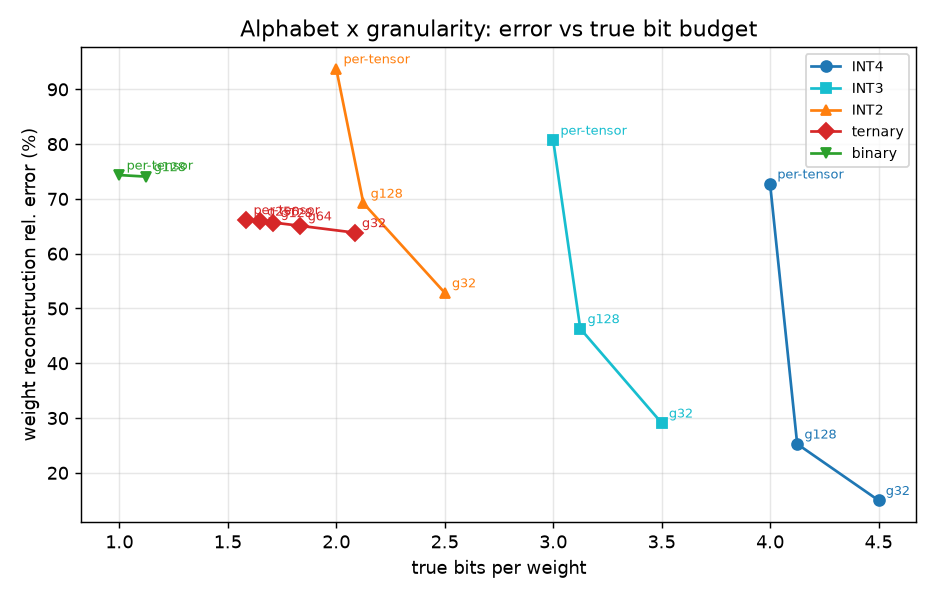

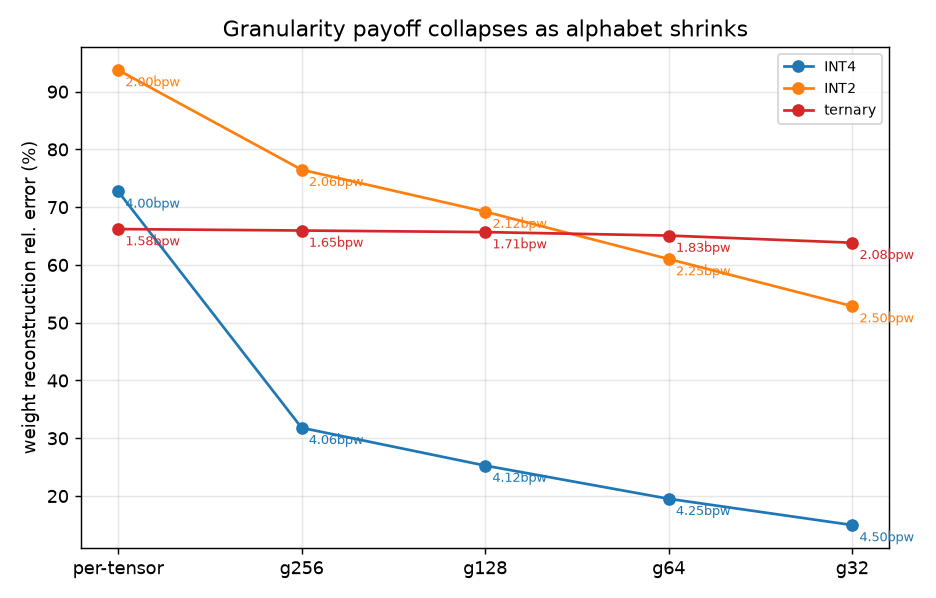

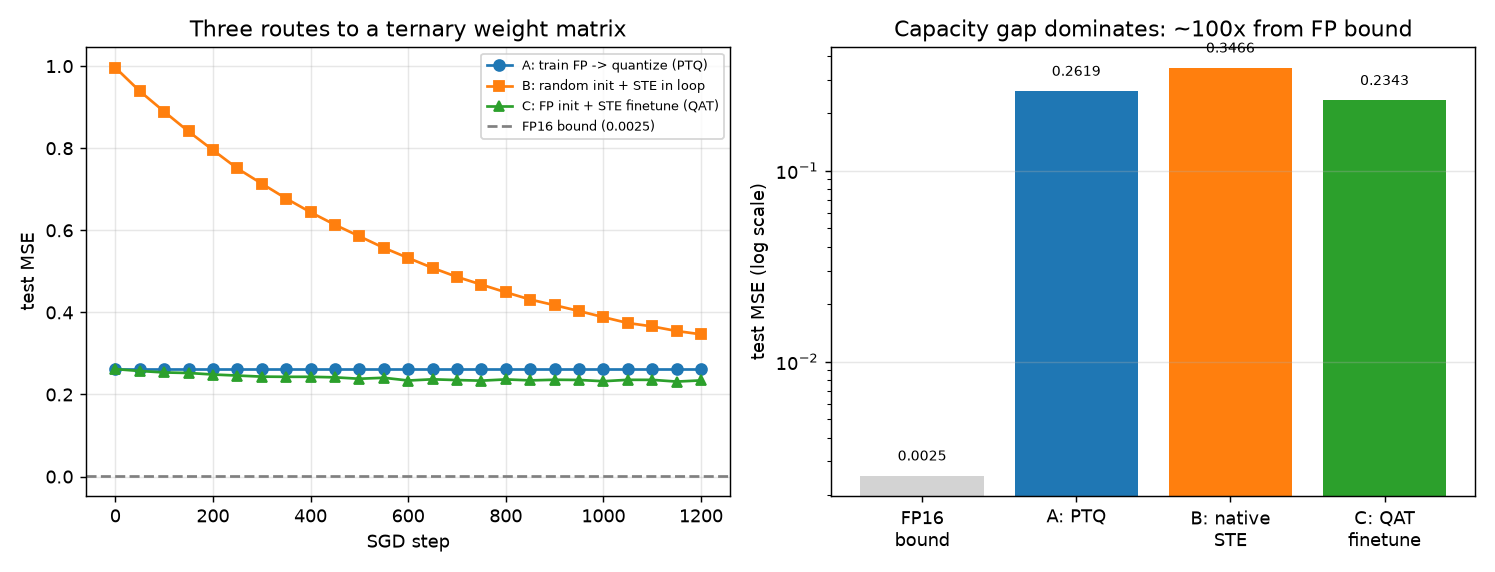

In [12]:
from IPython.display import Image, display

with open(os.path.join(OUT, "results.json"), "w") as f:
    json.dump(res, f, indent=2, ensure_ascii=False)
print("[results] results/results.json")

for p in (p1, p2, p3):
    display(Image(filename=p))

## 结论

1. **位宽账**：binary g128 = 1.125 bpw、ternary g128 = 1.710 bpw；但三元按 2-bit slot 实存就退化成 2.125，
   与 INT2 完全相同——**没有原生三元 kernel，1.71 只是纸面数字**。
2. **粒度边际收益随字母表变粗而坍塌**（79.4% → 43.6% → 3.6%）。位宽预算该花在哪，取决于字母表。
3. **三元码本比同 bpw 的均匀 INT2 更高效**（1.710 bpw / 65.69% vs 2.125 bpw / 69.23%），
   这是三元路线成立的信息论基础；但与 INT4（25.27%）仍有 2.4 倍误差差——**这就是必须用训练补偿的全部理由**。
4. **三条路径**：A 0.26194 / B 0.34660 / **C 0.23432**，而全精度上界 0.00253。
   B 反而输给 A（训练预算不足时 STE 起点太脏，原生低比特要靠海量 token 喂饱）；
   C 最优但只比 A 好 10.5%，距上界仍有 ~100 倍。
   **低比特的瓶颈是表示容量，不是优化器**——这正是 Bonsai 必须叠蒸馏、而不只是叠 STE 的原因。
5. **STE 是这条线的存在前提，不是优化技巧**：导数真的为 0 时，1200 步后误差等于初始值，训练完全停滞。